# Restaurant Revenue Prediction

**Author:** Nour Eldin Islam

**Dataset:** https://www.kaggle.com/datasets/mrsimple07/restaurants-revenue-prediction/data

## Objective

Predict a restaurant's monthly revenue from its business characteristics using supervised machine learning.

**Workflow followed:**
1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training
5. Model Evaluation & Comparison
6. Interpretation & Business Insights

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## 2. Load Dataset

In [5]:
df = pd.read_csv("Restaurant_revenue .csv")

df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


## 3. Dataset Overview

Before any analysis, we check the shape, data types, and summary statistics to understand what we're working with.

In [6]:
df.shape

(1000, 8)

In [7]:
df.dtypes

Number_of_Customers            int64
Menu_Price                   float64
Marketing_Spend              float64
Cuisine_Type                     str
Average_Customer_Spending    float64
Promotions                     int64
Reviews                        int64
Monthly_Revenue              float64
dtype: object

In [8]:
df.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.271000,30.219120,9.958726,29.477085,0.497000,49.837000,268.724172
std,26.364914,11.278760,5.845586,11.471686,0.500241,29.226334,103.982950
min,10.000000,10.009501,0.003768,10.037177,0.000000,0.000000,-28.977809
25%,30.000000,20.396828,4.690724,19.603041,0.000000,24.000000,197.103642
50%,54.000000,30.860614,10.092047,29.251365,0.000000,50.000000,270.213964
75%,74.000000,39.843868,14.992436,39.553220,1.000000,76.000000,343.395793
max,99.000000,49.974140,19.994276,49.900725,1.000000,99.000000,563.381332


### Feature Descriptions

| Feature | Data Type | Description |
|---------|-----------|-------------|
| Number_of_Customers | Integer | Number of customers visiting the restaurant. |
| Menu_Price | Float | Average price of items on the restaurant's menu. |
| Marketing_Spend | Float | Amount spent on marketing and advertising. |
| Cuisine_Type | Categorical | Type of cuisine served (Italian, Japanese, Mexican, American). |
| Average_Customer_Spending | Float | Average amount spent by each customer. |
| Promotions | Integer (0/1) | Whether a promotion or discount was active. |
| Reviews | Integer | Customer review score/count. |
| Monthly_Revenue | Float | **Target variable** — the restaurant's monthly revenue. |

## 4. Data Quality Checks

Checking for missing values and duplicate rows before doing any analysis, since both would distort our statistics and models if left unnoticed.

In [9]:
df.isnull().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

**Result:** no missing values and no duplicate rows. The dataset is structurally clean — any issues we find from here on will be about the *values themselves*, not completeness.

## 5. Exploratory Data Analysis (EDA)

The goal of EDA is to answer three questions before modeling:
1. Is the target well-behaved (shape, outliers, impossible values)?
2. Which features actually relate to the target, and how?
3. Are there data quality problems that preprocessing needs to address?

### 5.1 Distribution of Monthly Revenue

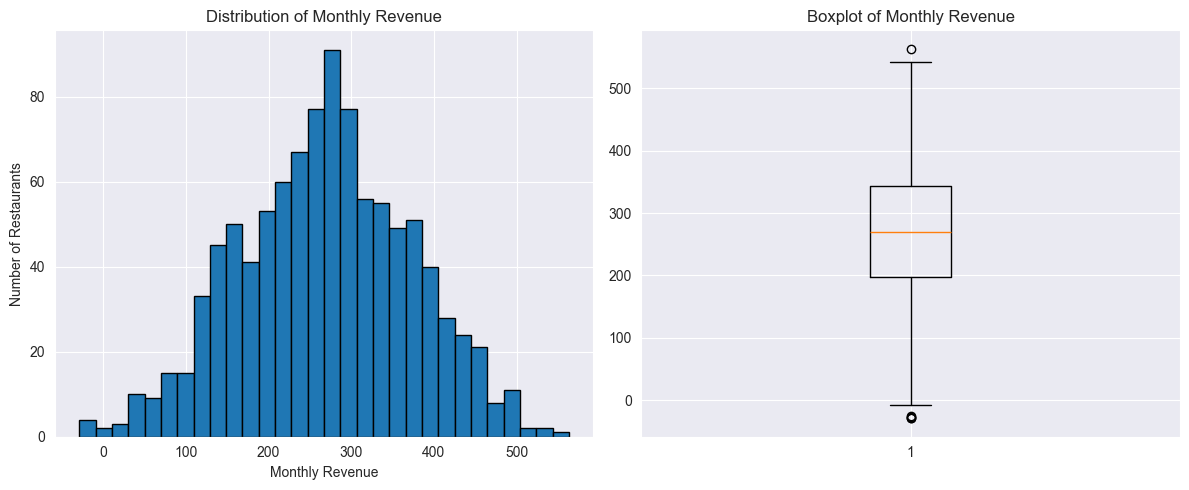

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["Monthly_Revenue"], bins=30, edgecolor="black")
axes[0].set_title("Distribution of Monthly Revenue")
axes[0].set_xlabel("Monthly Revenue")
axes[0].set_ylabel("Number of Restaurants")

axes[1].boxplot(df["Monthly_Revenue"])
axes[1].set_title("Boxplot of Monthly Revenue")

plt.tight_layout()
plt.show()

**Interpretation:** the distribution is approximately symmetric and bell-shaped, centered around 250-300. Skewness is close to 0, so no transformation (e.g. log) is needed for the target.

The boxplot shows a small cluster of points below the lower whisker — these are investigated next.

In [12]:
df[df["Monthly_Revenue"] <= 0]

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
54,11,32.620334,5.061169,American,33.761979,1,87,-28.977809
104,10,11.313867,2.279133,Italian,16.075447,1,24,-27.610276
110,17,22.458927,0.874713,American,35.280768,1,57,-25.453430
605,13,36.130521,0.811175,Mexican,43.119059,1,12,-28.920890
735,10,33.087409,6.009788,American,15.333779,1,31,-7.627382


**Interpretation:** 5 rows have negative Monthly_Revenue, and all 5 have very few customers (10-17, near the minimum of the dataset). Since revenue being negative is not logically meaningful for this target, these are treated as noise/impossible values and will be removed in preprocessing.

### 5.2 Numeric Features vs Monthly Revenue

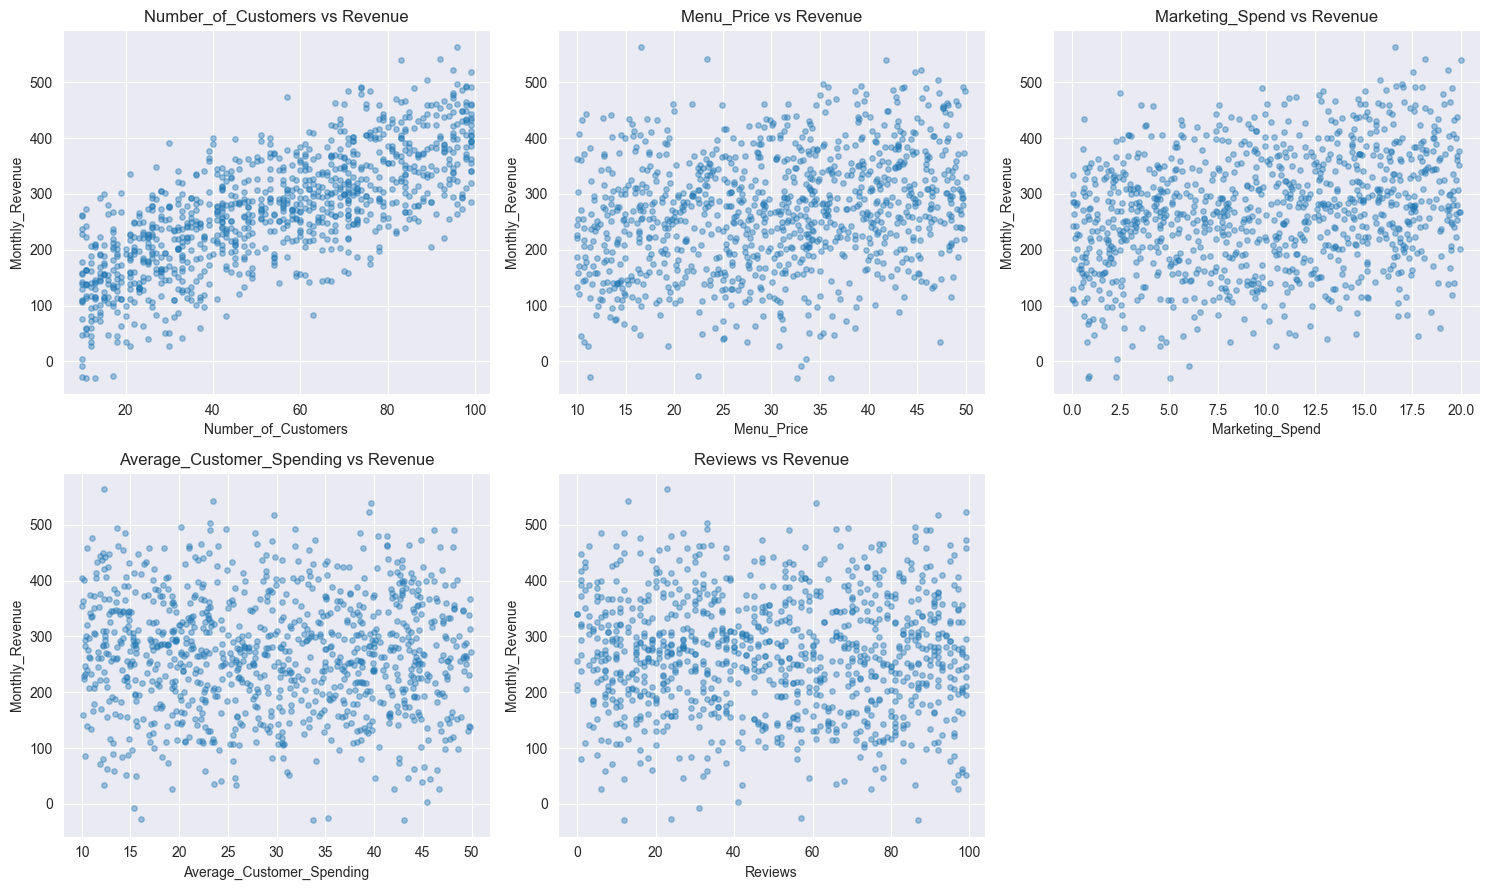

In [13]:
num_features = ["Number_of_Customers", "Menu_Price", "Marketing_Spend",
                "Average_Customer_Spending", "Reviews"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df["Monthly_Revenue"], alpha=0.4, s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Monthly_Revenue")
    axes[i].set_title(f"{col} vs Revenue")

axes[5].axis("off")
plt.tight_layout()
plt.show()

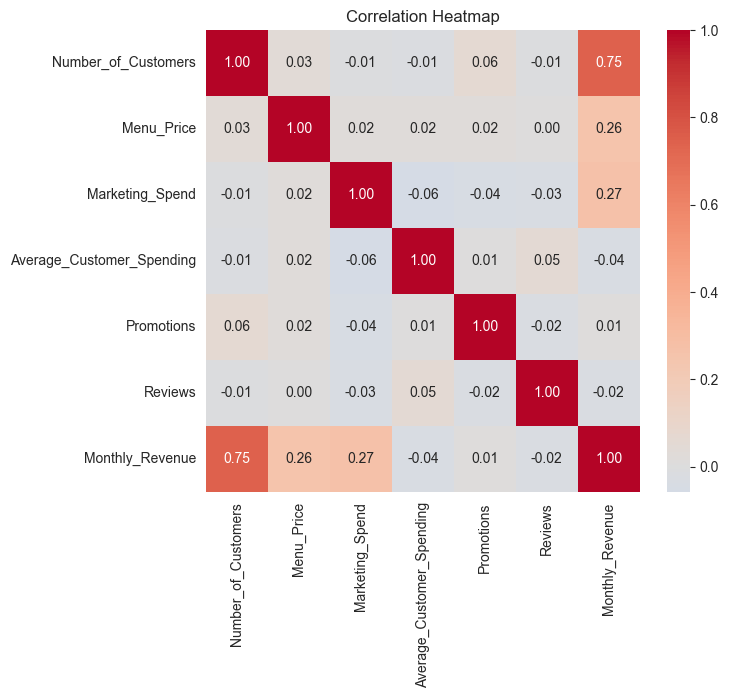

In [14]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**Interpretation:**
- `Number_of_Customers` has a strong, clearly linear relationship with revenue (correlation ≈ 0.75) — the dominant driver.
- `Menu_Price` and `Marketing_Spend` show weaker but real positive trends (correlation ≈ 0.26-0.27).
- `Average_Customer_Spending` and `Reviews` show flat, shapeless scatter plots and near-zero correlation (~ -0.02 to -0.04) — no detectable relationship, linear or otherwise.

### 5.3 Cuisine Type vs Revenue

A bar chart of group averages can be misleading on its own — some category will always look "highest," even if the difference is just noise. A one-way ANOVA test checks whether the differences between group means are larger than what random chance alone would produce.

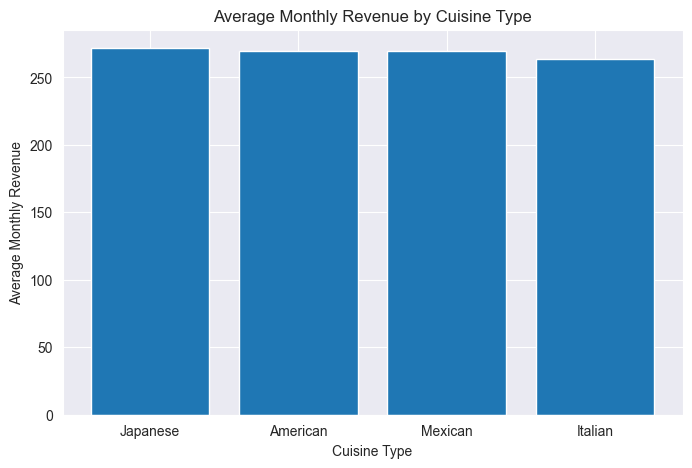

Cuisine_Type
Japanese    271.700186
American    269.604825
Mexican     269.366082
Italian     263.699862
Name: Monthly_Revenue, dtype: float64


In [15]:
avg_revenue = df.groupby("Cuisine_Type")["Monthly_Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(avg_revenue.index, avg_revenue.values)
plt.title("Average Monthly Revenue by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Monthly Revenue")
plt.show()

print(avg_revenue)

In [16]:
groups = [g["Monthly_Revenue"].values for _, g in df.groupby("Cuisine_Type")]
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat, " p-value:", p_value)

F-statistic: 0.2608015137894341  p-value: 0.8536504880046728


**Interpretation:** the bar chart alone suggests Japanese restaurants earn the most and Italian the least, but the gap (~8) is tiny relative to the overall spread of revenue (std ≈ 104). The ANOVA test confirms this: p-value ≈ 0.85, far above the 0.05 significance threshold. **Cuisine_Type has no statistically significant effect on revenue** — the bar chart differences are just noise. This feature will be dropped in preprocessing.

### 5.4 Promotions vs Revenue

Same logic as above, but for two groups instead of four, we use a t-test instead of ANOVA (the t-test is the two-group special case of ANOVA).

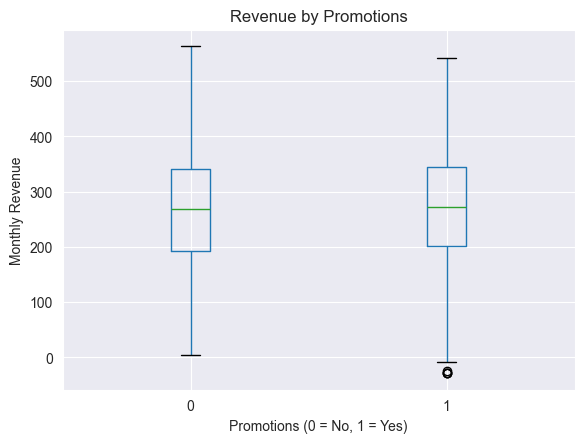

t-statistic: 0.4697754862690215  p-value: 0.638618055985493


In [17]:
df.boxplot(column="Monthly_Revenue", by="Promotions")
plt.title("Revenue by Promotions")
plt.suptitle("")
plt.xlabel("Promotions (0 = No, 1 = Yes)")
plt.ylabel("Monthly Revenue")
plt.show()

t_stat, p_value = stats.ttest_ind(
    df[df.Promotions == 1]["Monthly_Revenue"],
    df[df.Promotions == 0]["Monthly_Revenue"]
)
print("t-statistic:", t_stat, " p-value:", p_value)

**Interpretation:** mean revenue is nearly identical with vs without promotions (270.3 vs 267.2), and the t-test gives p ≈ 0.64 — not significant. Promotions do not show a detectable effect on revenue in this dataset.

### EDA Summary

| Finding | Decision for Preprocessing |
|---|---|
| Target is symmetric, no skew | No transformation needed |
| 5 rows have negative revenue (all very few customers) | **Drop these rows** |
| `Number_of_Customers`, `Menu_Price`, `Marketing_Spend` are real predictors | Keep |
| `Reviews`, `Average_Customer_Spending` show no relationship | Keep for now — will build a model with vs without these to test empirically |
| `Cuisine_Type` — no significant effect (ANOVA p=0.85) | **Drop this column** |
| `Promotions` — no significant effect (t-test p=0.64) | Keep for now — included in the "with weak features" comparison model |
| No missing values, no duplicates | Nothing to clean here |

## 6. Data Preprocessing

Based on the EDA findings above, we apply two changes before modeling:
1. Drop the 5 rows with negative `Monthly_Revenue` (impossible values).
2. Drop the `Cuisine_Type` column (no significant relationship with the target, confirmed by ANOVA).

In [18]:
df = df[df["Monthly_Revenue"] > 0]
df = df.drop(columns=["Cuisine_Type"])

df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,36.236133,0,45,350.912040
1,24,40.020077,4.577892,17.952562,0,36,221.319091
2,81,41.981485,4.652911,22.600420,1,91,326.529763
3,70,43.005307,4.416053,18.984098,1,59,348.190573
4,30,17.456199,3.475052,12.766143,1,30,185.009121


In [19]:
df.shape

(995, 7)

**Check:** shape should now be (995, 7) — 5 rows removed, 1 column removed. All remaining columns are numeric, so no further encoding is required.

## 7. Ready for Modeling

The dataset is now clean and fully numeric. Next steps: train/test split, then train two Linear Regression models —
- **Model A:** all remaining features (including the "weak" ones: `Average_Customer_Spending`, `Promotions`, `Reviews`)
- **Model B:** only the strong features (`Number_of_Customers`, `Menu_Price`, `Marketing_Spend`)

...and compare their performance on the same test set.